# Understanding Wide Sense Stationarity (WSS): mean and autocovariance:

## Methods of checking the assumptions

## <span style="background-color:#d8f8d8; padding:4px;">Weak-Sense Stationarity and Covariance Structure</span>

Before analyzing a signal, we often need to ask an important question:

> Are the statistical properties of this signal stable over time?

This question is related to **stationarity**.

A signal is called **stationary** if its statistical properties do not change as time passes. In simple words, the signal may fluctuate, but the rules generating those fluctuations stay the same over time.

For example, imagine recording EEG activity over many repeated trials.

If the signal is stationary, then the activity at the beginning, middle, and end of the recording should be generated by approximately the same statistical process. The exact values can change, but the general statistical behavior should remain stable.

If the signal is not stationary, then the signal’s properties may change over time. For example:

- the mean amplitude may drift upward or downward,
- the variance may increase or decrease,
- the relationship between nearby time points may change,
- the signal may become more or less correlated over time,
- artifacts, fatigue, adaptation, or experimental changes may alter the signal.

In real neuroscience and biomedical signals, nonstationarity is very common. EEG, ECG, EMG, local field potentials, spike rates, and behavioral signals can all change over time due to biological, experimental, or technical factors.

---

## <span style="background-color:#d8f8d8; padding:4px;">Why do we care about stationarity?</span>

Many signal-processing and statistical methods assume that the data are approximately stationary.

This matters because if the signal is stationary, we can often use one part of the signal to learn something about another part of the signal. In other words, the statistical structure is stable enough that estimates made from the data are meaningful over time.

For example, stationarity is important when we want to:

- estimate autocorrelation,
- estimate power spectra,
- compare trials,
- average across repeated recordings,
- fit time-series models,
- use Fourier-based methods,
- analyze noise properties,
- model EEG or neural signals,
- decide whether a signal segment is stable enough for further analysis.

If a signal is strongly nonstationary, then a single global estimate of the mean, variance, covariance, or spectrum may be misleading. The signal may need to be divided into smaller windows, detrended, filtered, normalized, or analyzed with methods designed for nonstationary data.

---

## <span style="background-color:#d8f8d8; padding:4px;">Strict stationarity vs weak-sense stationarity</span>

There are different levels of stationarity.

The strongest version is called **strict stationarity**. A strictly stationary process has the same full probability distribution over time. This means that all statistical properties remain unchanged if we shift the signal in time.

However, strict stationarity is difficult to test in practice because it involves the full probability distribution of the signal.

A more practical and commonly used version is **weak-sense stationarity**, also called **wide-sense stationarity** or **WSS**.

For WSS, we do not require the full probability distribution to stay the same. We only check two main properties:

1. The mean is constant over time.
2. The covariance depends only on the time lag, not on the absolute time.

So WSS is a weaker and more practical condition than strict stationarity.

---

## <span style="background-color:#d8f8d8; padding:4px;">Definition of weak-sense stationarity</span>

A signal or stochastic process $X(t)$ is weak-sense stationary if it satisfies two conditions.

### <span style="background-color:#d8f8d8; padding:4px;">Condition 1: Constant mean</span>

The expected value of the signal should not change over time:

$$
\mathbb{E}[X(t)] = \mu
$$

This means that the average value of the signal is the same for all time points.

In real data, we usually estimate this mean from repeated trials.

For example, if we have many trials, then for each time point $t$, we can compute the average across trials:

$$
\hat{\mu}(t) = \frac{1}{N}\sum_{i=1}^{N} X_i(t)
$$

where:

- $N$ is the number of trials,
- $X_i(t)$ is the value of trial $i$ at time $t$,
- $\hat{\mu}(t)$ is the estimated mean at time $t$.

For WSS, we expect $\hat{\mu}(t)$ to be approximately constant over time.

---

### <span style="background-color:#d8f8d8; padding:4px;">Condition 2: Covariance depends only on lag</span>

The second condition is about how the signal relates to itself at different time points.

For WSS, the covariance between two time points should depend only on the distance between those time points, not on their absolute location in time.

Mathematically:

$$
\operatorname{Cov}(X(t_1), X(t_2)) = C(t_2 - t_1)
$$

The quantity:

$$
t_2 - t_1
$$

is called the **lag**.

This means that the covariance between time 10 and time 20 should be similar to the covariance between time 100 and time 110, because both pairs are separated by the same lag.

In other words:

$$
\operatorname{Cov}(X(10), X(20))
$$

and

$$
\operatorname{Cov}(X(100), X(110))
$$

should be similar because both have lag:

$$
10
$$

For WSS, what matters is the distance between the time points, not the absolute time points themselves.

The core logic of the WSS property is therefore:

> If **Wide-Sense Stationarity (WSS)** is true, then for a fixed **lag**, the covariance should be approximately the same regardless of **where in time** you measure it.

If a diagonal in your covariance matrix contains values that vary significantly, it implies:

- **Same lag:** you are looking at the same relative distance between points.
- **Varying covariance:** the relationship between those points changes depending on **absolute time**.

This behavior is exactly what WSS does **not** allow. In a WSS process, the statistical properties, especially the mean and autocovariance, are invariant to a shift in time.

---

## <span style="background-color:#d8f8d8; padding:4px;">Intuition</span>

Imagine a signal where nearby time points tend to be similar.

For example, if the signal is high now, it may still be high a few milliseconds later. That means the signal has positive covariance at short lags.

But as the time points get farther apart, the relationship may become weaker. So the covariance may decrease as lag increases.

That is normal.

WSS does not require covariance to be the same for every lag. Instead, it requires that each lag behaves consistently across time.

So WSS allows this:

- lag 0 covariance may be high,
- lag 1 covariance may be slightly lower,
- lag 2 covariance may be lower,
- lag 10 covariance may be close to zero.

But WSS requires that all lag 1 relationships are similar to other lag 1 relationships, all lag 2 relationships are similar to other lag 2 relationships, and so on.

Therefore, WSS means:

> The covariance can change with lag, but it should not change with absolute time.

---

## <span style="background-color:#d8f8d8; padding:4px;">Why this is useful in trial-based data</span>

In many neuroscience experiments, we do not have only one signal. We often have many repeated trials.

For example, we may have:

- 200 trials,
- 500 time points per trial.

We can store this as a matrix:

$$
X \in \mathbb{R}^{N \times T}
$$

where:

- $N$ = number of trials,
- $T$ = number of time points,
- each row is one trial,
- each column is one time point.

So the data matrix looks like this:

$$
X =
\begin{bmatrix}
\text{trial 1 over time} \\
\text{trial 2 over time} \\
\vdots \\
\text{trial N over time}
\end{bmatrix}
$$

In this setting, we can estimate statistics across trials.

For example:

- To estimate the mean at time $t$, we average all trials at that time point.
- To estimate the variance at time $t$, we look at how much trial values vary at that time point.
- To estimate covariance between time $t_1$ and time $t_2$, we compare the vector of trial values at $t_1$ with the vector of trial values at $t_2$.

This is why the covariance matrix becomes very useful.

---

## <span style="background-color:#d8f8d8; padding:4px;">1. What are we trying to measure?</span>

For **WSS (Wide-Sense Stationarity)**, we care about the covariance between the signal at two times:

$$
\operatorname{Cov}(X(t_1), X(t_2))
$$

This asks:

> If the signal is high at time $t_1$, does it also tend to be high at time $t_2$?

Since we have many trials, we estimate this covariance **across trials**.

That means:

- Take all values at time $t_1$ from all trials.
- Take all values at time $t_2$ from all trials.
- Compute the covariance between those two vectors.

---

## <span style="background-color:#d8f8d8; padding:4px;">2. Why does this become a matrix?</span>

Because we can do this for **every pair of time points**.

If we have 500 time points, we can compute the covariance between:

- Time 1 and Time 1
- Time 1 and Time 2
- Time 1 and Time 3
- ...
- Time 500 and Time 500

So we get a table with:

- **Rows** = first time index, $t_1$
- **Columns** = second time index, $t_2$

That table is the **covariance matrix over time**:

$$
\Sigma =
\begin{bmatrix}
\operatorname{Cov}(X(1),X(1)) & \operatorname{Cov}(X(1),X(2)) & \cdots & \operatorname{Cov}(X(1),X(T)) \\
\operatorname{Cov}(X(2),X(1)) & \operatorname{Cov}(X(2),X(2)) & \cdots & \operatorname{Cov}(X(2),X(T)) \\
\vdots & \vdots & \ddots & \vdots \\
\operatorname{Cov}(X(T),X(1)) & \operatorname{Cov}(X(T),X(2)) & \cdots & \operatorname{Cov}(X(T),X(T))
\end{bmatrix}
$$

So the matrix entry $(t_1,t_2)$ is:

$$
\Sigma[t_1,t_2] = \operatorname{Cov}(X(t_1), X(t_2))
$$

---

## <span style="background-color:#d8f8d8; padding:4px;">3. What does one column $X(:,t)$ mean?</span>

This notation means:

$$
X(:,t) =
\begin{bmatrix}
X_1(t) \\
X_2(t) \\
\vdots \\
X_N(t)
\end{bmatrix}
$$

That is:

- **All trials**
- At **one fixed time point** $t$

So if $t=10$, then $X(:,10)$ is the vector of values measured at time point 10 across all trials.

For example, if we have 200 trials, then $X(:,10)$ contains 200 values.

---

## <span style="background-color:#d8f8d8; padding:4px;">4. Small example</span>

Let us use a tiny dataset with **3 trials** and **4 time points**.

$$
X =
\begin{bmatrix}
1 & 2 & 3 & 4 \\
2 & 3 & 4 & 5 \\
0 & 1 & 2 & 3
\end{bmatrix}
$$

Interpretation:

- **Trial 1:** $[1, 2, 3, 4]$
- **Trial 2:** $[2, 3, 4, 5]$
- **Trial 3:** $[0, 1, 2, 3]$

Now, extract the columns, meaning all trials at one fixed time point:

$$
X(:,1) =
\begin{bmatrix}
1 \\
2 \\
0
\end{bmatrix}
$$

$$
X(:,2) =
\begin{bmatrix}
2 \\
3 \\
1
\end{bmatrix}
$$

$$
X(:,3) =
\begin{bmatrix}
3 \\
4 \\
2
\end{bmatrix}
$$

$$
X(:,4) =
\begin{bmatrix}
4 \\
5 \\
3
\end{bmatrix}
$$

---

## <span style="background-color:#d8f8d8; padding:4px;">5. Compute one covariance entry by hand</span>

Let us compute:

$$
\operatorname{Cov}(X(:,1), X(:,2))
$$

We take:

$$
a =
\begin{bmatrix}
1 \\
2 \\
0
\end{bmatrix},
\qquad
b =
\begin{bmatrix}
2 \\
3 \\
1
\end{bmatrix}
$$

### Step 1: Compute means

$$
\bar{a} = \frac{1+2+0}{3} = 1
$$

$$
\bar{b} = \frac{2+3+1}{3} = 2
$$

### Step 2: Subtract means

$$
a-\bar{a} =
\begin{bmatrix}
0 \\
1 \\
-1
\end{bmatrix}
$$

$$
b-\bar{b} =
\begin{bmatrix}
0 \\
1 \\
-1
\end{bmatrix}
$$

### Step 3: Multiply elementwise

$$
(a-\bar{a})(b-\bar{b}) =
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}
$$

### Step 4: Sum

$$
0 + 1 + 1 = 2
$$

### Step 5: Divide by $n-1$

Using sample covariance:

$$
\operatorname{Cov}(a,b) = \frac{2}{3-1} = \frac{2}{2} = 1
$$

---

## <span style="background-color:#d8f8d8; padding:4px;">6. Build the whole covariance matrix</span>

If we do this for every pair of columns in our tiny dataset, we get:

$$
\Sigma =
\begin{bmatrix}
1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1
\end{bmatrix}
$$

Why all ones?

Because every column in our sample $X$ is just a shifted version of the others. Covariance ignores constant offsets, and the variance within each column is also 1.

---

## <span style="background-color:#d8f8d8; padding:4px;">7. What does the diagonal mean?</span>

The main diagonal entries are:

$$
\Sigma[t,t] = \operatorname{Cov}(X(t),X(t))
$$

This is the same as:

$$
\Sigma[t,t] = \operatorname{Var}(X(t))
$$

So the **main diagonal is the variance at each time point**.

For WSS, variance should be constant over time, so we would expect to see similar values along the main diagonal.

---

## <span style="background-color:#d8f8d8; padding:4px;">8. What do the off-diagonals mean?</span>

The off-diagonals tell us about covariance at different lags.

For example:

- The entry one step away from the main diagonal, $\Sigma[t, t+1]$, is the **covariance at lag 1**.
- The next one, $\Sigma[t, t+2]$, is the **covariance at lag 2**.
- The next one, $\Sigma[t, t+3]$, is the **covariance at lag 3**.

Each diagonal parallel to the main diagonal corresponds to one **fixed lag**.

For example, if you look at the **lag 1 diagonal**, you are looking at:

$$
\Sigma[1,2],\ \Sigma[2,3],\ \Sigma[3,4],\ \dots
$$

These are all covariances between time points separated by 1 sample.

For **WSS**, these should all be similar, because they all have the same lag.

---

## <span style="background-color:#d8f8d8; padding:4px;">9. Why is this useful for WSS?</span>

For WSS, covariance should depend only on the lag:

$$
\operatorname{Cov}(X(t_1),X(t_2)) = C(t_2-t_1)
$$

This means:

- All entries with lag 0, meaning the main diagonal, should be similar.
- All entries with lag 1 should be similar.
- All entries with lag 2 should be similar.
- All entries with the same lag should be similar.

In matrix language:

> The covariance matrix should look approximately constant along each diagonal.

This structure is called a **Toeplitz structure**.

An ideal WSS covariance matrix has the form:

$$
\Sigma =
\begin{bmatrix}
c_0 & c_1 & c_2 & c_3 \\
c_1 & c_0 & c_1 & c_2 \\
c_2 & c_1 & c_0 & c_1 \\
c_3 & c_2 & c_1 & c_0
\end{bmatrix}
$$

Notice:

- The main diagonal is all $c_0$.
- The first off-diagonals are all $c_1$.
- The second off-diagonals are all $c_2$.
- The third off-diagonals are all $c_3$.

That is what it means for the covariance to depend only on lag.

---

## <span style="background-color:#d8f8d8; padding:4px;">10. Concrete example of a WSS-like covariance matrix</span>

Suppose:

$$
\Sigma =
\begin{bmatrix}
2.0 & 1.5 & 0.8 & 0.2 \\
1.5 & 2.0 & 1.5 & 0.8 \\
0.8 & 1.5 & 2.0 & 1.5 \\
0.2 & 0.8 & 1.5 & 2.0
\end{bmatrix}
$$

Interpretation:

- **Variance** is always $2.0$, because the main diagonal is constant.
- **Lag 1 covariance** is always $1.5$, because the first off-diagonal is constant.
- **Lag 2 covariance** is always $0.8$, because the second off-diagonal is constant.
- **Lag 3 covariance** is always $0.2$, because the third off-diagonal is constant.

This is exactly what **WSS** wants.

The structure is consistent along every diagonal.

---

## <span style="background-color:#d8f8d8; padding:4px;">11. Example of a nonstationary covariance matrix</span>

Now suppose:

$$
\Sigma =
\begin{bmatrix}
1.0 & 0.5 & 0.2 & 0.1 \\
0.5 & 2.0 & 0.7 & 0.3 \\
0.2 & 0.7 & 3.0 & 1.1 \\
0.1 & 0.3 & 1.1 & 4.0
\end{bmatrix}
$$

Now notice the inconsistencies:

- **Variance changes over time:** $1.0, 2.0, 3.0, 4.0$.
- **Same lag does not give the same covariance:** look at the first off-diagonal; the values are $0.5, 0.7, 1.1$.

Even though the lag is always 1, the strength of the relationship is increasing over time.

So this does **not** look WSS.

The statistical properties are shifting as absolute time progresses.

---

## <span style="background-color:#d8f8d8; padding:4px;">12. Why the mean of a diagonal is not enough</span>

When analyzing covariance matrices for WSS, it is common to summarize each diagonal.

For example, for each lag, we may compute:

- the mean covariance along that diagonal,
- the standard deviation along that diagonal.

The mean tells us the average covariance for that lag.

However, the mean alone can hide important nonstationary structure.

---

### <span style="background-color:#d8f8d8; padding:4px;">Step 1: A good WSS-like diagonal</span>

Suppose that for lag 1, we get these values:

$$
[0.82,\ 0.79,\ 0.81,\ 0.80]
$$

Their mean is:

$$
\frac{0.82+0.79+0.81+0.80}{4}=0.805
$$

Their spread is very small.

This is good because it says:

- covariance at lag 1 is about 0.8,
- it stays about 0.8 across time.

That is consistent with WSS.

---

### <span style="background-color:#d8f8d8; padding:4px;">Step 2: A bad diagonal with a misleading mean</span>

Now suppose that for lag 1, we get:

$$
[0.9,\ 0.9,\ 0.1,\ 0.1]
$$

The mean is:

$$
\frac{0.9+0.9+0.1+0.1}{4}=0.5
$$

If you only look at the mean, you might say:

> Covariance at lag 1 is 0.5.

But that is misleading.

Why?

Because the actual values are not centered around 0.5. Instead, they split into two very different regimes:

- **Early in time:** covariance is 0.9.
- **Later in time:** covariance is 0.1.

So the covariance at lag 1 is **not stable across time**. That suggests nonstationarity.

---

### <span style="background-color:#d8f8d8; padding:4px;">Step 3: Why the mean hides the problem</span>

Averaging compresses everything into one number.

The mean of:

$$
[0.9,\ 0.9,\ 0.1,\ 0.1]
$$

is the same as the mean of:

$$
[0.5,\ 0.5,\ 0.5,\ 0.5]
$$

Both give:

$$
0.5
$$

But these two diagonals mean completely different things.

### Case A

$$
[0.5,\ 0.5,\ 0.5,\ 0.5]
$$

This means:

- the diagonal is perfectly consistent,
- same lag, same covariance everywhere,
- this is very WSS-like.

### Case B

$$
[0.9,\ 0.9,\ 0.1,\ 0.1]
$$

This means:

- the diagonal is inconsistent,
- same lag, but covariance changes with absolute time,
- this is not WSS-like.

So the mean alone cannot tell these cases apart.

---

### <span style="background-color:#d8f8d8; padding:4px;">Step 4: Why standard deviation helps</span>

The standard deviation measures how spread out the values are around the mean.

For a consistent diagonal:

$$
[0.5,\ 0.5,\ 0.5,\ 0.5]
$$

the standard deviation is:

$$
0
$$

This tells us there is no spread and the diagonal is very consistent.

For an inconsistent diagonal:

$$
[0.9,\ 0.9,\ 0.1,\ 0.1]
$$

the mean is:

$$
0.5
$$

but the standard deviation is large.

This tells us that:

- the values are far from the mean,
- the diagonal is not internally consistent,
- the covariance depends on more than just the lag,
- the covariance also depends on absolute time.

---

## <span style="background-color:#d8f8d8; padding:4px;">13. Tiny covariance-matrix comparison using diagonal consistency</span>

Let us build two $4 \times 4$ covariance matrices to visualize the difference.

### <span style="background-color:#d8f8d8; padding:4px;">Matrix A: WSS-like</span>

$$
\Sigma_A =
\begin{bmatrix}
1.0 & 0.5 & 0.2 & 0.1 \\
0.5 & 1.0 & 0.5 & 0.2 \\
0.2 & 0.5 & 1.0 & 0.5 \\
0.1 & 0.2 & 0.5 & 1.0
\end{bmatrix}
$$

Look at the **lag 1 diagonal**:

$$
[0.5,\ 0.5,\ 0.5]
$$

Its mean is:

$$
0.5
$$

Its standard deviation is:

$$
0
$$

This is exactly what WSS likes:

> Same lag, same covariance.

---

### <span style="background-color:#d8f8d8; padding:4px;">Matrix B: Nonstationary</span>

$$
\Sigma_B =
\begin{bmatrix}
1.0 & 0.9 & 0.2 & 0.1 \\
0.9 & 1.0 & 0.9 & 0.2 \\
0.2 & 0.9 & 1.0 & 0.1 \\
0.1 & 0.2 & 0.1 & 1.0
\end{bmatrix}
$$

Now the **lag 1 diagonal** is:

$$
[0.9,\ 0.9,\ 0.1]
$$

Its mean is:

$$
\frac{0.9+0.9+0.1}{3} = 0.6333
$$

That mean is not representative of the actual structure because two entries are near $0.9$ and one is near $0.1$.

The diagonal is inconsistent, suggesting:

1. At **early times**, lag 1 covariance is strong.
2. At **later times**, lag 1 covariance is weak.

That is evidence **against WSS**.

---

### <span style="background-color:#d8f8d8; padding:4px;">Standard deviation calculation for Matrix B</span>

Let us calculate the standard deviation of the lag-1 diagonal from Matrix B.

The lag-1 diagonal is:

$$
d = [0.9,\ 0.9,\ 0.1]
$$

### Step 1: Compute the mean

$$
\bar{d} = \frac{0.9+0.9+0.1}{3}
$$

$$
\bar{d} = \frac{1.9}{3} \approx 0.6333
$$

### Step 2: Compute each deviation from the mean

Subtract the mean from each value:

$$
0.9 - 0.6333 = 0.2667
$$

$$
0.9 - 0.6333 = 0.2667
$$

$$
0.1 - 0.6333 = -0.5333
$$

So the deviations are:

$$
[0.2667,\ 0.2667,\ -0.5333]
$$

### Step 3: Square the deviations

$$
(0.2667)^2 \approx 0.0711
$$

$$
(0.2667)^2 \approx 0.0711
$$

$$
(-0.5333)^2 \approx 0.2844
$$

So the squared deviations are:

$$
[0.0711,\ 0.0711,\ 0.2844]
$$

### Step 4: Average those squared deviations

There are two conventions depending on whether we are treating this diagonal as the whole population or as a sample.

#### Population standard deviation $\sigma$

Divide by:

$$
n = 3
$$

$$
\frac{0.0711+0.0711+0.2844}{3}
=
\frac{0.4266}{3}
=
0.1422
$$

Take the square root:

$$
\sigma = \sqrt{0.1422} \approx 0.377
$$

#### Sample standard deviation $s$

Divide by:

$$
n - 1 = 2
$$

$$
\frac{0.4266}{2}
=
0.2133
$$

Take the square root:

$$
s = \sqrt{0.2133} \approx 0.462
$$

The standard deviation is not small relative to the values in the diagonal.

This confirms that the lag-1 covariance is not stable across time.

---

## <span style="background-color:#d8f8d8; padding:4px;">Final intuition</span>

Weak-sense stationarity is useful because it gives us a simple way to ask whether the signal is statistically stable over time.

For WSS, we mainly check:

1. Is the mean approximately constant over time?
2. Is the variance approximately constant over time?
3. Does covariance depend mostly on lag, rather than absolute time?

In matrix form, the key visual idea is:

> A WSS covariance matrix should look approximately constant along its diagonals.

If the main diagonal changes strongly, the variance is changing over time.

If the off-diagonals are inconsistent, then the covariance depends on absolute time, not only on lag.

That suggests the signal is not weak-sense stationary.

Therefore, when checking WSS from a covariance matrix, it is not enough to only compute the mean of each diagonal. We also need to inspect the spread of each diagonal, for example using the standard deviation.

A small standard deviation along a fixed-lag diagonal supports WSS-like behavior.

A large standard deviation along a fixed-lag diagonal suggests that the covariance changes with absolute time, which is evidence against WSS.

## <span style="background-color:#d8f8d8; padding:4px;">Example:</span>

## Relevance of computing the std in the covariance matrix and not only the mean

## Relevance of computing the standard deviation in the covariance matrix and not only the mean

In the previous explanation, we saw that for a signal to be approximately **weak-sense stationary**, the covariance should depend mainly on the **lag** and not on the **absolute time**.

This means that if we look at one diagonal of the covariance matrix, the values along that diagonal should be approximately consistent.

For example:

- The main diagonal corresponds to **lag 0**, which is the variance at each time point.
- The first off-diagonal corresponds to **lag 1**.
- The second off-diagonal corresponds to **lag 2**.
- And so on.

So, if we take the lag-1 diagonal:

$$
\Sigma[1,2],\ \Sigma[2,3],\ \Sigma[3,4],\ \dots
$$

we are looking at the covariance between time points separated by one sample.

For WSS, all these values should be similar because they all represent the same lag.

---

## Why the mean alone is not enough

A common first idea is to summarize each diagonal by its mean.

For example, we may say:

> The average covariance at lag 1 is 0.5.

However, the mean alone can be misleading.

Consider these two lag-1 diagonals:

$$
[0.5,\ 0.5,\ 0.5]
$$

and

$$
[0.9,\ 0.9,\ 0.1]
$$

Both can be summarized by a single mean value, but they represent very different situations.

The first diagonal is very consistent. The covariance is the same at every position along the diagonal.

The second diagonal is inconsistent. The covariance is high at some positions and much lower at another position. This suggests that the relationship between points separated by the same lag changes depending on where we are in time.

That is not compatible with WSS.

---

## Why the standard deviation is useful

The standard deviation tells us how much the values along a diagonal vary around their mean.

If the standard deviation is small, then the diagonal values are close to each other.

This suggests:

> Same lag, similar covariance across time.

That is WSS-like.

If the standard deviation is large, then the diagonal values are spread out.

This suggests:

> Same lag, but covariance changes depending on absolute time.

That is evidence against WSS.

So, when checking WSS using a covariance matrix, it is useful to compute both:

$$
\text{mean of each diagonal}
$$

and

$$
\text{standard deviation of each diagonal}
$$

The mean tells us the average covariance for that lag.

The standard deviation tells us whether that covariance is stable along the diagonal.

---

## What this code example does

The code below creates two artificial covariance matrices.

One matrix is **consistent** and WSS-like.

The other matrix is **inconsistent** and nonstationary-like.

Then the code extracts the lag-1 diagonal from each matrix, computes its mean and standard deviation step by step, and finally plots both the full matrices and their lag-1 diagonals.

---

### Matrix 1: Consistent / WSS-like

The first matrix is:

$$
\Sigma_{\text{consistent}} =
\begin{bmatrix}
1.0 & 0.5 & 0.2 & 0.1 \\
0.5 & 1.0 & 0.5 & 0.2 \\
0.2 & 0.5 & 1.0 & 0.5 \\
0.1 & 0.2 & 0.5 & 1.0
\end{bmatrix}
$$

Its lag-1 diagonal is:

$$
[0.5,\ 0.5,\ 0.5]
$$

This diagonal has:

- mean = 0.5,
- standard deviation = 0.

This is perfectly consistent.

The covariance at lag 1 is the same across time, which is what we expect in a WSS-like covariance matrix.

---

### Matrix 2: Inconsistent / nonstationary-like

The second matrix is:

$$
\Sigma_{\text{inconsistent}} =
\begin{bmatrix}
1.0 & 0.9 & 0.2 & 0.1 \\
0.9 & 1.0 & 0.9 & 0.2 \\
0.2 & 0.9 & 1.0 & 0.1 \\
0.1 & 0.2 & 0.1 & 1.0
\end{bmatrix}
$$

Its lag-1 diagonal is:

$$
[0.9,\ 0.9,\ 0.1]
$$

This diagonal has a much larger spread.

Although we can compute a mean, that mean does not describe the diagonal well, because the covariance is not stable across time.

This suggests nonstationarity.

---

## Step-by-step calculations in the code

The function:

```python
def explain_mean_std(name, d):
    ...
````
takes one diagonal vector, such as:

$$
d = [0.9,\ 0.9,\ 0.1]
$$

and computes:

1. The mean.
2. The deviations from the mean.
3. The squared deviations.
4. The population variance.
5. The population standard deviation.

This is useful because it makes explicit how the standard deviation detects inconsistency along a covariance diagonal.

---

## What the plots show

The code produces a figure with four panels.

### Top-left panel

This shows the consistent covariance matrix.

The values follow a WSS-like structure because each diagonal is internally consistent.

### Top-right panel

This shows the inconsistent covariance matrix.

Some values along the same diagonal differ strongly, suggesting that covariance depends on absolute time.

### Bottom-left panel

This shows the lag-1 diagonal of the consistent matrix:

$$
[0.5,\ 0.5,\ 0.5]
$$

The mean line overlaps perfectly with the values, and the standard deviation band is essentially zero.

This means the diagonal is stable.

### Bottom-right panel

This shows the lag-1 diagonal of the inconsistent matrix:

$$
[0.9,\ 0.9,\ 0.1]
$$

Here, the values are far from being constant along the diagonal.

The standard deviation band is much larger, showing that the mean alone is not enough to describe the covariance at lag 1.

---

## Main idea

For WSS, it is not enough to ask:

> What is the average covariance at each lag?

We also need to ask:

> Is the covariance at that lag stable across time?

The mean answers the first question.

The standard deviation answers the second question.

Therefore, when evaluating WSS from a covariance matrix, computing the standard deviation along each diagonal helps detect whether the signal is truly WSS-like or whether the apparent average covariance hides nonstationary structure.


CONSISTENT DIAGONAL: lag 1 from Sigma_consistent
Diagonal values: [0.5 0.5 0.5]

STEP 1: Mean
mean = (0.500 + 0.500 + 0.500) / 3
mean = 1.500 / 3
mean = 0.500000

STEP 2: Deviations from the mean
value 0: 0.500 - 0.500000 = 0.000000
value 1: 0.500 - 0.500000 = 0.000000
value 2: 0.500 - 0.500000 = 0.000000

STEP 3: Squared deviations
(0.000000)^2 = 0.000000
(0.000000)^2 = 0.000000
(0.000000)^2 = 0.000000

STEP 4: Population variance
variance = (0.000000 + 0.000000 + 0.000000) / 3
variance = 0.000000 / 3
variance = 0.000000

STEP 5: Population standard deviation
std = sqrt(0.000000)
std = 0.000000

INCONSISTENT DIAGONAL: lag 1 from Sigma_inconsistent
Diagonal values: [0.9 0.9 0.1]

STEP 1: Mean
mean = (0.900 + 0.900 + 0.100) / 3
mean = 1.900 / 3
mean = 0.633333

STEP 2: Deviations from the mean
value 0: 0.900 - 0.633333 = 0.266667
value 1: 0.900 - 0.633333 = 0.266667
value 2: 0.100 - 0.633333 = -0.533333

STEP 3: Squared deviations
(0.266667)^2 = 0.071111
(0.266667)^2 = 0.071111
(-0.533

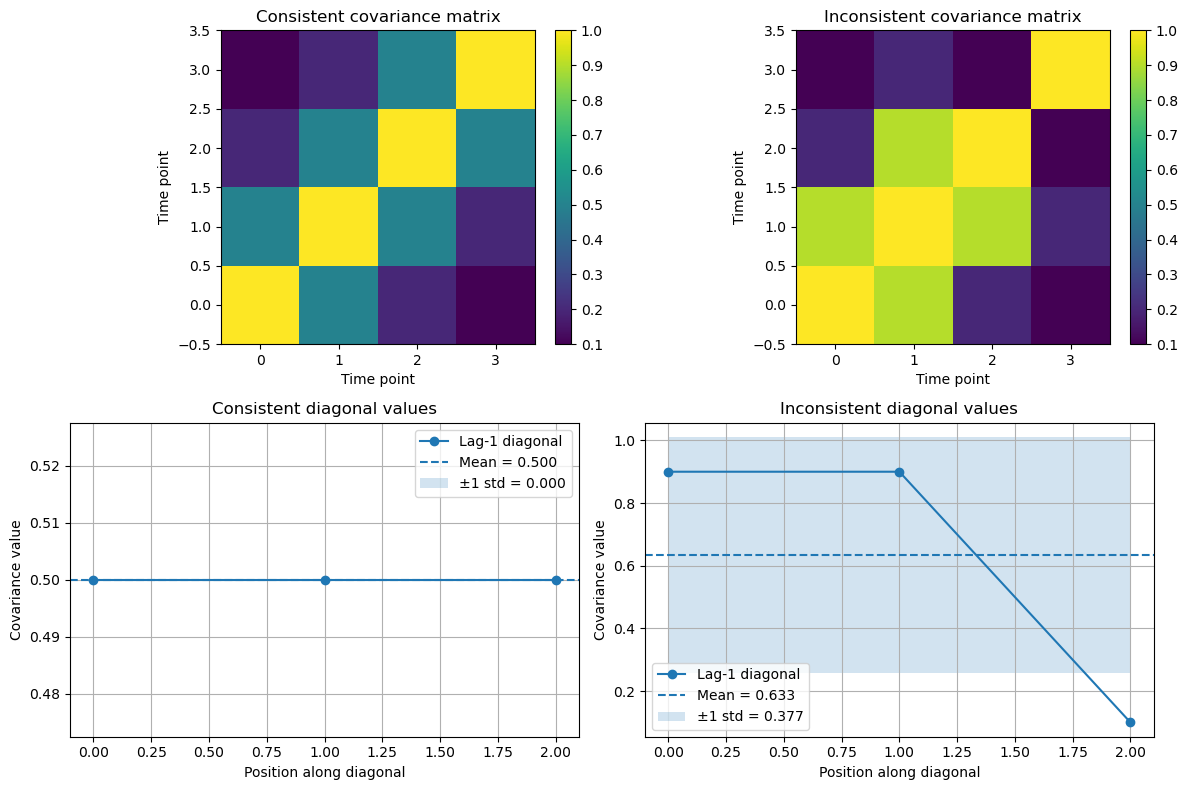

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Goal of this code
# ------------------------------------------------------------
# We want to show why, when checking weak-sense stationarity (WSS),
# it is not enough to compute only the mean of each covariance diagonal.
#
# For WSS:
#   Covariance should depend mainly on the lag.
#
# In a covariance matrix:
#   - Main diagonal      -> lag 0
#   - First off-diagonal -> lag 1
#   - Second off-diagonal -> lag 2
#
# Therefore, values along the same diagonal should be similar.
#
# The mean tells us the average covariance at a given lag.
# The standard deviation tells us whether that covariance is stable
# along the diagonal.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. Define two example covariance matrices
# ------------------------------------------------------------

# Matrix A: consistent / WSS-like covariance matrix
# ------------------------------------------------------------
# This matrix is WSS-like because each diagonal is internally consistent.
#
# For example, the lag-1 diagonal is:
#
#   [0.5, 0.5, 0.5]
#
# These values are all equal.
# This means that covariance at lag 1 is the same across time.
#
# Interpretation:
#   Same lag -> same covariance
#
# This is what we expect from a WSS process.

Sigma_consistent = np.array([
    [1.0, 0.5, 0.2, 0.1],
    [0.5, 1.0, 0.5, 0.2],
    [0.2, 0.5, 1.0, 0.5],
    [0.1, 0.2, 0.5, 1.0]
])


# Matrix B: inconsistent / nonstationary-like covariance matrix
# ------------------------------------------------------------
# This matrix is nonstationary-like because values along the same
# diagonal are not consistent.
#
# For example, the lag-1 diagonal is:
#
#   [0.9, 0.9, 0.1]
#
# These values are not equal.
# This means that covariance at lag 1 changes depending on where
# we are in time.
#
# Interpretation:
#   Same lag -> different covariance at different absolute times
#
# This is evidence against WSS.

Sigma_inconsistent = np.array([
    [1.0, 0.9, 0.2, 0.1],
    [0.9, 1.0, 0.9, 0.2],
    [0.2, 0.9, 1.0, 0.1],
    [0.1, 0.2, 0.1, 1.0]
])


# ------------------------------------------------------------
# 2. Extract the lag-1 diagonal from each matrix
# ------------------------------------------------------------
# np.diag(matrix, k=0) extracts the main diagonal.
# np.diag(matrix, k=1) extracts the first diagonal above the main diagonal.
# np.diag(matrix, k=2) extracts the second diagonal above the main diagonal.
#
# Here, k=1 means we extract the lag-1 diagonal:
#
#   Sigma[0,1], Sigma[1,2], Sigma[2,3]
#
# These entries compare time points separated by one time step.

diag_consistent = np.diag(Sigma_consistent, k=1)
diag_inconsistent = np.diag(Sigma_inconsistent, k=1)


# ------------------------------------------------------------
# 3. Define a helper function to explain mean and standard deviation
# ------------------------------------------------------------
# This function prints the computation step by step.
#
# It is useful because it shows exactly how the standard deviation
# captures the spread of values along one covariance diagonal.
#
# A small standard deviation means:
#   Values along the diagonal are similar.
#   The covariance for that lag is stable across time.
#
# A large standard deviation means:
#   Values along the diagonal are different.
#   The covariance for that lag changes with absolute time.
# ------------------------------------------------------------

def explain_mean_std(name, d):
    """
    Compute and print the mean and population standard deviation
    of one covariance diagonal.

    Parameters
    ----------
    name : str
        A label describing the diagonal being analyzed.

    d : numpy.ndarray
        A one-dimensional array containing the values from one
        diagonal of a covariance matrix.

    Returns
    -------
    mean_d : float
        The mean value of the diagonal.

    std_pop : float
        The population standard deviation of the diagonal.
    """

    # Number of values in this diagonal.
    n = len(d)

    # --------------------------------------------------------
    # Mean
    # --------------------------------------------------------
    # The mean gives the average covariance value for this lag.
    #
    # However, the mean does not tell us whether the values
    # are stable along the diagonal.

    mean_d = np.mean(d)

    # --------------------------------------------------------
    # Deviations from the mean
    # --------------------------------------------------------
    # Each deviation tells us how far one diagonal value is from
    # the average diagonal value.

    deviations = d - mean_d

    # --------------------------------------------------------
    # Squared deviations
    # --------------------------------------------------------
    # We square deviations so that positive and negative deviations
    # do not cancel each other out.

    sq_dev = deviations ** 2

    # --------------------------------------------------------
    # Population variance
    # --------------------------------------------------------
    # The variance is the average squared deviation from the mean.
    #
    # Here we use population variance because we are treating this
    # small diagonal as the full object we want to describe.

    var_pop = np.mean(sq_dev)

    # --------------------------------------------------------
    # Population standard deviation
    # --------------------------------------------------------
    # The standard deviation is the square root of the variance.
    #
    # It is in the same units as the covariance values, so it is
    # easier to interpret than variance.

    std_pop = np.sqrt(var_pop)

    # --------------------------------------------------------
    # Print results step by step
    # --------------------------------------------------------

    print(f"\n{'=' * 60}")
    print(f"{name}")
    print(f"{'=' * 60}")
    print(f"Diagonal values: {d}")

    # Step 1: Mean
    values_sum_str = " + ".join([f"{x:.3f}" for x in d])

    print("\nSTEP 1: Mean")
    print(f"mean = ({values_sum_str}) / {n}")
    print(f"mean = {np.sum(d):.3f} / {n}")
    print(f"mean = {mean_d:.6f}")

    # Step 2: Deviations
    print("\nSTEP 2: Deviations from the mean")

    for i, x in enumerate(d):
        print(f"value {i}: {x:.3f} - {mean_d:.6f} = {deviations[i]:.6f}")

    # Step 3: Squared deviations
    print("\nSTEP 3: Squared deviations")

    for i in range(n):
        print(f"({deviations[i]:.6f})^2 = {sq_dev[i]:.6f}")

    # Step 4: Variance
    sq_sum_str = " + ".join([f"{x:.6f}" for x in sq_dev])

    print("\nSTEP 4: Population variance")
    print(f"variance = ({sq_sum_str}) / {n}")
    print(f"variance = {np.sum(sq_dev):.6f} / {n}")
    print(f"variance = {var_pop:.6f}")

    # Step 5: Standard deviation
    print("\nSTEP 5: Population standard deviation")
    print(f"std = sqrt({var_pop:.6f})")
    print(f"std = {std_pop:.6f}")

    return mean_d, std_pop


# ------------------------------------------------------------
# 4. Compute and print mean/std for both lag-1 diagonals
# ------------------------------------------------------------

# For the WSS-like matrix, we expect:
#   mean = 0.5
#   std  = 0
#
# Because all lag-1 values are identical.

mean_consistent, std_consistent = explain_mean_std(
    "CONSISTENT DIAGONAL: lag 1 from Sigma_consistent",
    diag_consistent
)


# For the nonstationary-like matrix, we expect:
#   mean to be somewhere between 0.9 and 0.1,
#   but std to be large.
#
# The large standard deviation reveals that the mean is hiding
# instability along the diagonal.

mean_inconsistent, std_inconsistent = explain_mean_std(
    "INCONSISTENT DIAGONAL: lag 1 from Sigma_inconsistent",
    diag_inconsistent
)


# ------------------------------------------------------------
# 5. Plot the covariance matrices and their lag-1 diagonals
# ------------------------------------------------------------
# The top row shows the full covariance matrices.
# The bottom row shows only the lag-1 diagonal values.
#
# The dashed horizontal line is the mean.
# The shaded band is mean ± 1 standard deviation.
#
# Interpretation:
#   - If the shaded band is tiny, the diagonal is consistent.
#   - If the shaded band is large, the diagonal is inconsistent.
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))


# ------------------------------------------------------------
# Top-left: WSS-like covariance matrix
# ------------------------------------------------------------

im0 = axes[0, 0].imshow(
    Sigma_consistent,
    cmap="viridis",
    origin="lower"
)

axes[0, 0].set_title("Consistent covariance matrix")
axes[0, 0].set_xlabel("Time point")
axes[0, 0].set_ylabel("Time point")

plt.colorbar(
    im0,
    ax=axes[0, 0],
    fraction=0.046,
    pad=0.04
)


# ------------------------------------------------------------
# Top-right: nonstationary-like covariance matrix
# ------------------------------------------------------------

im1 = axes[0, 1].imshow(
    Sigma_inconsistent,
    cmap="viridis",
    origin="lower"
)

axes[0, 1].set_title("Inconsistent covariance matrix")
axes[0, 1].set_xlabel("Time point")
axes[0, 1].set_ylabel("Time point")

plt.colorbar(
    im1,
    ax=axes[0, 1],
    fraction=0.046,
    pad=0.04
)


# ------------------------------------------------------------
# Bottom-left: lag-1 diagonal of the WSS-like matrix
# ------------------------------------------------------------
# Because all values are 0.5, the mean line overlaps with
# the diagonal values and the standard deviation band has zero width.

x_consistent = np.arange(len(diag_consistent))

axes[1, 0].plot(
    x_consistent,
    diag_consistent,
    marker="o",
    label="Lag-1 diagonal"
)

axes[1, 0].axhline(
    mean_consistent,
    linestyle="--",
    label=f"Mean = {mean_consistent:.3f}"
)

axes[1, 0].fill_between(
    x_consistent,
    mean_consistent - std_consistent,
    mean_consistent + std_consistent,
    alpha=0.2,
    label=f"±1 std = {std_consistent:.3f}"
)

axes[1, 0].set_title("Consistent diagonal values")
axes[1, 0].set_xlabel("Position along diagonal")
axes[1, 0].set_ylabel("Covariance value")
axes[1, 0].legend()
axes[1, 0].grid(True)


# ------------------------------------------------------------
# Bottom-right: lag-1 diagonal of the nonstationary-like matrix
# ------------------------------------------------------------
# The values [0.9, 0.9, 0.1] are not stable along the diagonal.
#
# The mean gives one summary value, but the standard deviation band
# shows that the diagonal has large spread.

x_inconsistent = np.arange(len(diag_inconsistent))

axes[1, 1].plot(
    x_inconsistent,
    diag_inconsistent,
    marker="o",
    label="Lag-1 diagonal"
)

axes[1, 1].axhline(
    mean_inconsistent,
    linestyle="--",
    label=f"Mean = {mean_inconsistent:.3f}"
)

axes[1, 1].fill_between(
    x_inconsistent,
    mean_inconsistent - std_inconsistent,
    mean_inconsistent + std_inconsistent,
    alpha=0.2,
    label=f"±1 std = {std_inconsistent:.3f}"
)

axes[1, 1].set_title("Inconsistent diagonal values")
axes[1, 1].set_xlabel("Position along diagonal")
axes[1, 1].set_ylabel("Covariance value")
axes[1, 1].legend()
axes[1, 1].grid(True)


# ------------------------------------------------------------
# 6. Final layout adjustment and display
# ------------------------------------------------------------

plt.tight_layout()
plt.show()

## Step-by-step example: mean, covariance, autocovariance, and autocorrelation

In this example, we use a small trial-based dataset to calculate:

1. The mean at each time point.
2. The covariance matrix across time.
3. The autocovariance at lags 0, 1, 2, and 3.
4. The autocorrelation at lags 0, 1, 2, and 3.

The goal is to see what WSS means in practice:

> WSS does **not** mean that all covariances must be equal.

Instead, WSS means that the covariance depends only on the **lag**.

So it is allowed that:

- lag 0 covariance is high,
- lag 1 covariance is lower,
- lag 2 covariance is lower,
- lag 3 covariance is lower.

But all covariance values with the same lag should be similar.

That means:

- all lag 0 values should be similar,
- all lag 1 values should be similar,
- all lag 2 values should be similar,
- all lag 3 values should be similar.

---

## 1. Data matrix

Suppose we have 8 trials and 4 time points.

Each row is one trial.  
Each column is one time point.

$$
X =
\begin{bmatrix}
4 & 4 & 4 & 4 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
2 & 0 & -2 & -4 \\
-2 & 0 & -2 & 0 \\
-2 & -4 & -2 & 0 \\
-2 & 0 & 2 & 0
\end{bmatrix}
$$

So:

- Column 1 is time point 1.
- Column 2 is time point 2.
- Column 3 is time point 3.
- Column 4 is time point 4.

We can write the columns as:

$$
X(:,1) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 2 \\ -2 \\ -2 \\ -2
\end{bmatrix}
$$

$$
X(:,2) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0
\end{bmatrix}
$$

$$
X(:,3) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -2 \\ -2 \\ -2 \\ 2
\end{bmatrix}
$$

$$
X(:,4) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0 \\ 0 \\ 0
\end{bmatrix}
$$

---

## 2. Mean at each time point

The mean at each time point is computed across trials.

For time point 1:

$$
\bar{X}(1) =
\frac{4+0+0+0+2-2-2-2}{8}
=
\frac{0}{8}
=
0
$$

For time point 2:

$$
\bar{X}(2) =
\frac{4+0+0+0+0+0-4+0}{8}
=
\frac{0}{8}
=
0
$$

For time point 3:

$$
\bar{X}(3) =
\frac{4+0+0+0-2-2-2+2}{8}
=
\frac{0}{8}
=
0
$$

For time point 4:

$$
\bar{X}(4) =
\frac{4+0+0+0-4+0+0+0}{8}
=
\frac{0}{8}
=
0
$$

So the mean vector is:

$$
\mu =
\begin{bmatrix}
0 & 0 & 0 & 0
\end{bmatrix}
$$

This satisfies the first WSS requirement in this example:

> The mean is constant over time.

Because the mean is 0 at every time point, we do not need to subtract anything when computing covariance.

However, this is only because the mean is zero in this specific example.

In general, when the mean is not zero, we **must** subtract the mean from each time-point column before computing covariance. This is explained in the next section.

---

## 3. Covariance formula

The sample covariance between two time points $t_i$ and $t_j$ is:

$$
\operatorname{Cov}(X(t_i), X(t_j))
=
\frac{1}{N-1}
\sum_{r=1}^{N}
\left(X_r(t_i)-\bar{X}(t_i)\right)
\left(X_r(t_j)-\bar{X}(t_j)\right)
$$

where:

- $N$ is the number of trials,
- here $N=8$,
- $r$ indexes the trial,
- $X_r(t_i)$ is the value of trial $r$ at time point $t_i$,
- $\bar{X}(t_i)$ is the mean across trials at time point $t_i$,
- $\bar{X}(t_j)$ is the mean across trials at time point $t_j$.

Since all means are zero in our main example, this becomes:

$$
\operatorname{Cov}(X(t_i), X(t_j))
=
\frac{1}{7}
\sum_{r=1}^{8}
X_r(t_i)X_r(t_j)
$$

because:

$$
N-1 = 8-1 = 7
$$

So for this example, we can multiply the two columns directly.

But this simplification is only valid because:

$$
\bar{X}(1)=\bar{X}(2)=\bar{X}(3)=\bar{X}(4)=0
$$

---

## 3.1. What if the mean is not zero?

If the mean is not zero, we need to use the full covariance formula.

The important rule is:

> You subtract the mean inside each column/time point before multiplying the two columns together.

The covariance between two time points is:

$$
\operatorname{Cov}(X(t_i), X(t_j))
=
\frac{1}{N-1}
\sum_{r=1}^{N}
\left(X_r(t_i)-\bar{X}(t_i)\right)
\left(X_r(t_j)-\bar{X}(t_j)\right)
$$

So if the mean is not zero, you do this:

For time point $t_i$:

$$
X(:,t_i) - \bar{X}(t_i)
$$

For time point $t_j$:

$$
X(:,t_j) - \bar{X}(t_j)
$$

Then you multiply those two mean-centered columns trial by trial.

---

### Example with non-zero means

Suppose:

$$
X(:,1)=
\begin{bmatrix}
5\\
3\\
1
\end{bmatrix}
$$

and

$$
X(:,2)=
\begin{bmatrix}
6\\
4\\
2
\end{bmatrix}
$$

We want to compute:

$$
\operatorname{Cov}(X(1),X(2))
$$

---

### Step 1: Compute the means

For time point 1:

$$
\bar{X}(1)=\frac{5+3+1}{3}=3
$$

For time point 2:

$$
\bar{X}(2)=\frac{6+4+2}{3}=4
$$

---

### Step 2: Subtract the mean from each column

For time point 1:

$$
X(:,1)-\bar{X}(1)
=
\begin{bmatrix}
5-3\\
3-3\\
1-3
\end{bmatrix}
=
\begin{bmatrix}
2\\
0\\
-2
\end{bmatrix}
$$

For time point 2:

$$
X(:,2)-\bar{X}(2)
=
\begin{bmatrix}
6-4\\
4-4\\
2-4
\end{bmatrix}
=
\begin{bmatrix}
2\\
0\\
-2
\end{bmatrix}
$$

---

### Step 3: Multiply trial by trial

Now multiply the centered values:

$$
(2)(2)=4
$$

$$
(0)(0)=0
$$

$$
(-2)(-2)=4
$$

---

### Step 4: Sum

$$
4+0+4=8
$$

---

### Step 5: Divide by $N-1$

There are 3 trials, so:

$$
N=3
$$

and:

$$
N-1=2
$$

Therefore:

$$
\operatorname{Cov}(X(1),X(2)) = \frac{8}{3-1}
$$

$$
\operatorname{Cov}(X(1),X(2)) = \frac{8}{2}=4
$$

---

### Key idea

You do **not** subtract one global mean from the whole matrix.

You subtract the **mean of each time point from that same time point’s column**.

So for the covariance between $X(t_1)$ and $X(t_2)$, you subtract:

$$
\bar{X}(t_1)
$$

from all values in column $t_1$, and subtract:

$$
\bar{X}(t_2)
$$

from all values in column $t_2$.

Then you multiply the centered columns.

---

## 4. Lag 0 covariance: variance at each time point

Lag 0 means that we compare each time point with itself.

So lag 0 corresponds to the main diagonal of the covariance matrix:

$$
\operatorname{Cov}(X(1),X(1)),
\operatorname{Cov}(X(2),X(2)),
\operatorname{Cov}(X(3),X(3)),
\operatorname{Cov}(X(4),X(4))
$$

Because each time point is compared with itself, lag 0 is the variance at each time point.

---

### Time point 1 variance

$$
X(:,1) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 2 \\ -2 \\ -2 \\ -2
\end{bmatrix}
$$

Because the mean is 0:

$$
\operatorname{Var}(X(1))
=
\frac{4^2+0^2+0^2+0^2+2^2+(-2)^2+(-2)^2+(-2)^2}{7}
$$

$$
=
\frac{16+0+0+0+4+4+4+4}{7}
$$

$$
=
\frac{32}{7}
=
4.571
$$

---

### Time point 2 variance

$$
X(:,2) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0
\end{bmatrix}
$$

$$
\operatorname{Var}(X(2))
=
\frac{4^2+0^2+0^2+0^2+0^2+0^2+(-4)^2+0^2}{7}
$$

$$
=
\frac{16+16}{7}
=
\frac{32}{7}
=
4.571
$$

---

### Time point 3 variance

$$
X(:,3) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -2 \\ -2 \\ -2 \\ 2
\end{bmatrix}
$$

$$
\operatorname{Var}(X(3))
=
\frac{4^2+0^2+0^2+0^2+(-2)^2+(-2)^2+(-2)^2+2^2}{7}
$$

$$
=
\frac{16+4+4+4+4}{7}
=
\frac{32}{7}
=
4.571
$$

---

### Time point 4 variance

$$
X(:,4) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0 \\ 0 \\ 0
\end{bmatrix}
$$

$$
\operatorname{Var}(X(4))
=
\frac{4^2+0^2+0^2+0^2+(-4)^2+0^2+0^2+0^2}{7}
$$

$$
=
\frac{16+16}{7}
=
\frac{32}{7}
=
4.571
$$

So all lag 0 covariance values are:

$$
\left[
\frac{32}{7},
\frac{32}{7},
\frac{32}{7},
\frac{32}{7}
\right]
$$

or approximately:

$$
[4.571,\ 4.571,\ 4.571,\ 4.571]
$$

This is WSS-like because the variance is constant over time.

---

## 5. Lag 1 covariance

Lag 1 means we compare time points separated by one sample.

The rule is:

$$
\operatorname{Cov}(X(t),X(t+1))
$$

So with four time points, lag 1 contains:

$$
\operatorname{Cov}(X(1),X(2)),
\operatorname{Cov}(X(2),X(3)),
\operatorname{Cov}(X(3),X(4))
$$

These are the first off-diagonal values of the covariance matrix.

---

### Covariance between time 1 and time 2

$$
X(:,1) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 2 \\ -2 \\ -2 \\ -2
\end{bmatrix}
$$

$$
X(:,2) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0
\end{bmatrix}
$$

Multiply trial by trial:

$$
(4)(4)=16
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(2)(0)=0
$$

$$
(-2)(0)=0
$$

$$
(-2)(-4)=8
$$

$$
(-2)(0)=0
$$

Now sum:

$$
16+0+0+0+0+0+8+0=24
$$

Divide by 7:

$$
\operatorname{Cov}(X(1),X(2))
=
\frac{24}{7}
=
3.429
$$

---

### Covariance between time 2 and time 3

$$
X(:,2) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0
\end{bmatrix}
$$

$$
X(:,3) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -2 \\ -2 \\ -2 \\ 2
\end{bmatrix}
$$

Multiply trial by trial:

$$
(4)(4)=16
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(0)(-2)=0
$$

$$
(0)(-2)=0
$$

$$
(-4)(-2)=8
$$

$$
(0)(2)=0
$$

Sum:

$$
16+0+0+0+0+0+8+0=24
$$

Divide by 7:

$$
\operatorname{Cov}(X(2),X(3))
=
\frac{24}{7}
=
3.429
$$

---

### Covariance between time 3 and time 4

$$
X(:,3) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -2 \\ -2 \\ -2 \\ 2
\end{bmatrix}
$$

$$
X(:,4) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0 \\ 0 \\ 0
\end{bmatrix}
$$

Multiply trial by trial:

$$
(4)(4)=16
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(-2)(-4)=8
$$

$$
(-2)(0)=0
$$

$$
(-2)(0)=0
$$

$$
(2)(0)=0
$$

Sum:

$$
16+0+0+0+8+0+0+0=24
$$

Divide by 7:

$$
\operatorname{Cov}(X(3),X(4))
=
\frac{24}{7}
=
3.429
$$

So all lag 1 covariance values are:

$$
\left[
\frac{24}{7},
\frac{24}{7},
\frac{24}{7}
\right]
$$

or approximately:

$$
[3.429,\ 3.429,\ 3.429]
$$

This is WSS-like because all lag 1 relationships are the same.

---

## 6. Lag 2 covariance

Lag 2 means we compare time points separated by two samples.

The rule is:

$$
\operatorname{Cov}(X(t),X(t+2))
$$

So with four time points, lag 2 contains:

$$
\operatorname{Cov}(X(1),X(3)),
\operatorname{Cov}(X(2),X(4))
$$

---

### Covariance between time 1 and time 3

$$
X(:,1) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 2 \\ -2 \\ -2 \\ -2
\end{bmatrix}
$$

$$
X(:,3) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -2 \\ -2 \\ -2 \\ 2
\end{bmatrix}
$$

Multiply trial by trial:

$$
(4)(4)=16
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(2)(-2)=-4
$$

$$
(-2)(-2)=4
$$

$$
(-2)(-2)=4
$$

$$
(-2)(2)=-4
$$

Sum:

$$
16+0+0+0-4+4+4-4=16
$$

Divide by 7:

$$
\operatorname{Cov}(X(1),X(3))
=
\frac{16}{7}
=
2.286
$$

---

### Covariance between time 2 and time 4

$$
X(:,2) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0
\end{bmatrix}
$$

$$
X(:,4) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0 \\ 0 \\ 0
\end{bmatrix}
$$

Multiply trial by trial:

$$
(4)(4)=16
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(0)(-4)=0
$$

$$
(0)(0)=0
$$

$$
(-4)(0)=0
$$

$$
(0)(0)=0
$$

Sum:

$$
16+0+0+0+0+0+0+0=16
$$

Divide by 7:

$$
\operatorname{Cov}(X(2),X(4))
=
\frac{16}{7}
=
2.286
$$

So all lag 2 covariance values are:

$$
\left[
\frac{16}{7},
\frac{16}{7}
\right]
$$

or approximately:

$$
[2.286,\ 2.286]
$$

This is WSS-like because all lag 2 relationships are the same.

---

## 7. Lag 3 covariance

Lag 3 means we compare time points separated by three samples.

The rule is:

$$
\operatorname{Cov}(X(t),X(t+3))
$$

So with four time points, lag 3 contains only:

$$
\operatorname{Cov}(X(1),X(4))
$$

---

### Covariance between time 1 and time 4

$$
X(:,1) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ 2 \\ -2 \\ -2 \\ -2
\end{bmatrix}
$$

$$
X(:,4) =
\begin{bmatrix}
4 \\ 0 \\ 0 \\ 0 \\ -4 \\ 0 \\ 0 \\ 0
\end{bmatrix}
$$

Multiply trial by trial:

$$
(4)(4)=16
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(0)(0)=0
$$

$$
(2)(-4)=-8
$$

$$
(-2)(0)=0
$$

$$
(-2)(0)=0
$$

$$
(-2)(0)=0
$$

Sum:

$$
16+0+0+0-8+0+0+0=8
$$

Divide by 7:

$$
\operatorname{Cov}(X(1),X(4))
=
\frac{8}{7}
=
1.143
$$

So lag 3 covariance is:

$$
\left[
\frac{8}{7}
\right]
$$

or approximately:

$$
[1.143]
$$

---

## 8. Full covariance matrix

Now we can place all values into the full covariance matrix:

$$
\Sigma =
\begin{bmatrix}
\frac{32}{7} & \frac{24}{7} & \frac{16}{7} & \frac{8}{7} \\
\frac{24}{7} & \frac{32}{7} & \frac{24}{7} & \frac{16}{7} \\
\frac{16}{7} & \frac{24}{7} & \frac{32}{7} & \frac{24}{7} \\
\frac{8}{7} & \frac{16}{7} & \frac{24}{7} & \frac{32}{7}
\end{bmatrix}
$$

Approximately:

$$
\Sigma =
\begin{bmatrix}
4.571 & 3.429 & 2.286 & 1.143 \\
3.429 & 4.571 & 3.429 & 2.286 \\
2.286 & 3.429 & 4.571 & 3.429 \\
1.143 & 2.286 & 3.429 & 4.571
\end{bmatrix}
$$

This is a very clear WSS-like covariance matrix because each diagonal is constant.

---

## 9. Autocovariance by lag

The autocovariance function summarizes covariance as a function of lag.

For this example:

### Lag 0

$$
\gamma(0) =
\frac{32}{7}
=
4.571
$$

### Lag 1

$$
\gamma(1) =
\frac{24}{7}
=
3.429
$$

### Lag 2

$$
\gamma(2) =
\frac{16}{7}
=
2.286
$$

### Lag 3

$$
\gamma(3) =
\frac{8}{7}
=
1.143
$$

So the autocovariance sequence is:

$$
\gamma(k) =
\left[
\frac{32}{7},
\frac{24}{7},
\frac{16}{7},
\frac{8}{7}
\right]
$$

or approximately:

$$
[4.571,\ 3.429,\ 2.286,\ 1.143]
$$

This shows the important WSS idea:

> Covariance can decrease as lag increases, but values with the same lag should be stable across time.

---

## 10. Autocorrelation by lag

Autocorrelation is the normalized version of autocovariance.

It is computed as:

$$
\rho(k) =
\frac{\gamma(k)}{\gamma(0)}
$$

where:

- $\gamma(k)$ is autocovariance at lag $k$,
- $\gamma(0)$ is variance.

Since:

$$
\gamma(0)=\frac{32}{7}
$$

we get:

### Lag 0

$$
\rho(0)
=
\frac{\gamma(0)}{\gamma(0)}
=
1
$$

### Lag 1

$$
\rho(1)
=
\frac{\gamma(1)}{\gamma(0)}
=
\frac{24/7}{32/7}
=
\frac{24}{32}
=
0.75
$$

### Lag 2

$$
\rho(2)
=
\frac{\gamma(2)}{\gamma(0)}
=
\frac{16/7}{32/7}
=
\frac{16}{32}
=
0.5
$$

### Lag 3

$$
\rho(3)
=
\frac{\gamma(3)}{\gamma(0)}
=
\frac{8/7}{32/7}
=
\frac{8}{32}
=
0.25
$$

So the autocorrelation sequence is:

$$
\rho(k) =
[1,\ 0.75,\ 0.5,\ 0.25]
$$

---

## 11. Interpretation for WSS

This example is WSS-like because the mean is constant:

$$
\mu =
[0,\ 0,\ 0,\ 0]
$$

and the covariance depends only on lag.

The covariance matrix is:

$$
\Sigma =
\begin{bmatrix}
4.571 & 3.429 & 2.286 & 1.143 \\
3.429 & 4.571 & 3.429 & 2.286 \\
2.286 & 3.429 & 4.571 & 3.429 \\
1.143 & 2.286 & 3.429 & 4.571
\end{bmatrix}
$$

Reading by diagonals:

- Lag 0: $[4.571,\ 4.571,\ 4.571,\ 4.571]$
- Lag 1: $[3.429,\ 3.429,\ 3.429]$
- Lag 2: $[2.286,\ 2.286]$
- Lag 3: $[1.143]$

Notice that lag 0 is higher than lag 1, lag 1 is higher than lag 2, and lag 2 is higher than lag 3.

That is completely allowed under WSS.

WSS does not require all lags to have the same covariance.

WSS requires that the covariance for the same lag is consistent across time.

So the key idea is:

$$
\operatorname{Cov}(X(t), X(t+k)) = \gamma(k)
$$

meaning that covariance depends on the lag $k$, not on the absolute time $t$.

---

## 12. What happens to the autocovariance vector if the process is not WSS?

In the WSS-like example, the autocovariance vector has size 4 because we have 4 possible lags:

$$
k = 0, 1, 2, 3
$$

and because the covariance values inside each lag were identical, we could summarize each lag with one clean value:

$$
\gamma = [\gamma(0), \gamma(1), \gamma(2), \gamma(3)]
$$

For example:

$$
\gamma = [4.571,\ 3.429,\ 2.286,\ 1.143]
$$

But this works cleanly only because the covariance matrix was WSS-like.

---

### If values inside one lag are not the same

If values inside one lag are not the same, then you no longer have one unique covariance value for that lag.

For example, suppose lag 1 has:

$$
[3.4,\ 2.7,\ 1.1]
$$

These are all lag-1 covariance values:

$$
\operatorname{Cov}(X(t_1),X(t_2)),\quad
\operatorname{Cov}(X(t_2),X(t_3)),\quad
\operatorname{Cov}(X(t_3),X(t_4))
$$

but they are not equal.

So instead of saying:

$$
\gamma(1)=3.4
$$

or:

$$
\gamma(1)=2.7
$$

or:

$$
\gamma(1)=1.1
$$

we have to say:

$$
\text{lag 1 covariance values} = [3.4,\ 2.7,\ 1.1]
$$

That means the covariance depends not only on the lag, but also on where you are in time.

In other words:

$$
\operatorname{Cov}(X(t),X(t+1))
$$

is not constant across $t$.

That is evidence against WSS.

---

### Option 1: Keep the full covariance-by-lag lists

Instead of one autocovariance vector, you keep a dictionary or list of vectors:

$$
\text{lag 0}: [4.5,\ 5.0,\ 6.2,\ 7.1]
$$

$$
\text{lag 1}: [3.4,\ 2.7,\ 1.1]
$$

$$
\text{lag 2}: [2.0,\ 0.8]
$$

$$
\text{lag 3}: [0.3]
$$

This is the most honest representation, because it shows that same-lag covariances are not stable.

So the “covariance vector” is no longer just:

$$
[\gamma(0),\gamma(1),\gamma(2),\gamma(3)]
$$

Instead, it becomes something like:

$$
\{
0: [\Sigma_{1,1}, \Sigma_{2,2}, \Sigma_{3,3}, \Sigma_{4,4}],
\quad
1: [\Sigma_{1,2}, \Sigma_{2,3}, \Sigma_{3,4}],
\quad
2: [\Sigma_{1,3}, \Sigma_{2,4}],
\quad
3: [\Sigma_{1,4}]
\}
$$

That tells you:

> Here are all covariance values for each lag.

---

### Option 2: Summarize each lag with a mean and standard deviation

Sometimes we still want a compact autocovariance-like summary.

Then we can compute the mean of each diagonal:

$$
\bar{\gamma}(0) = \text{mean of lag 0 diagonal}
$$

$$
\bar{\gamma}(1) = \text{mean of lag 1 diagonal}
$$

$$
\bar{\gamma}(2) = \text{mean of lag 2 diagonal}
$$

$$
\bar{\gamma}(3) = \text{mean of lag 3 diagonal}
$$

This gives a vector like:

$$
\bar{\gamma} = [5.7,\ 2.4,\ 1.4,\ 0.3]
$$

But now we should also report the standard deviation for each lag:

$$
\text{std}_{\gamma} = [1.0,\ 1.2,\ 0.6,\ 0]
$$

The mean tells us the average covariance at each lag.

The standard deviation tells us whether that average is trustworthy.

For example, if:

$$
\text{lag 1} = [3.4,\ 2.7,\ 1.1]
$$

then the mean is:

$$
\bar{\gamma}(1) = \frac{3.4+2.7+1.1}{3} = 2.4
$$

But the values are spread out, so the mean hides the fact that covariance changes over time.

That is why we also compute the standard deviation.

---

### Main conclusion for the non-WSS case

If the timepoint covariances inside one lag are not the same, then the process is not clearly WSS.

The most complete representation is not a single autocovariance vector, but a set of covariance values for each lag:

$$
\text{lag 0}: [\cdots]
$$

$$
\text{lag 1}: [\cdots]
$$

$$
\text{lag 2}: [\cdots]
$$

$$
\text{lag 3}: [\cdots]
$$

Then, if you want a compact summary, you can compute:

$$
\text{mean covariance per lag}
$$

plus:

$$
\text{standard deviation per lag}
$$

The WSS-like case is the special case where the standard deviation inside each lag is approximately zero.

---

## 13. Summary

This example shows:

1. The mean is constant over time:

$$
[0,\ 0,\ 0,\ 0]
$$

2. The variance is constant over time:

$$
\gamma(0) = 4.571
$$

3. Lag 1 covariance is stable across time:

$$
[3.429,\ 3.429,\ 3.429]
$$

4. Lag 2 covariance is stable across time:

$$
[2.286,\ 2.286]
$$

5. Lag 3 covariance is:

$$
[1.143]
$$

6. Autocovariance decreases with lag:

$$
[4.571,\ 3.429,\ 2.286,\ 1.143]
$$

7. Autocorrelation also decreases with lag:

$$
[1,\ 0.75,\ 0.5,\ 0.25]
$$

This is exactly the type of pattern we expect from a WSS-like signal.

The key conceptual point is:

> WSS does not require all lags to have the same covariance.

Instead:

> WSS requires all covariance values with the same lag to be approximately equal.

If that is true, then we can summarize the covariance structure using a clean autocovariance vector:

$$
\gamma = [\gamma(0),\gamma(1),\gamma(2),\gamma(3)]
$$

If that is not true, then we should keep the full covariance-by-lag lists or summarize each lag using both the mean and the standard deviation.